# Insurance Cost Analysis & Regression - Medical Cost Personal Dataset

This notebook explores the *Medical Cost Personal Dataset* (Kaggle) to understand
which factors drive individual medical insurance charges.

We will:
- perform a thorough **statistical analysis** (descriptive + inferential),
- build and interpret **single-level linear regression models** (full, reduced, Box-Cox, robust inference),
- validate predictive performance **out-of-sample** (train/test, k-fold, baseline comparison),
- run a **multilevel feasibility check** using region as grouping factor,
- and conclude with a final model recommendation for portfolio and business use.

**Business question**

> Which factors explain individual medical insurance costs, and what is the
> average effect of age, BMI and smoking habits on charges, with quantified uncertainty?

**Dataset**
- Each row: one insured individual
- Target variable (y): `charges` (medical insurance cost)
- Features (X): `age`, `bmi`, `smoker`, `children`, `sex`, `region`
- Source: [Kaggle - Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

> **Note (Portugues):** Este projeto foi desenvolvido como parte do meu portfolio
> de Data Science, com foco em fundamentos estatisticos e regressao linear aplicados
> a custos de seguro saude.


## Notebook Roadmap

1. Context & data loading
2. Exploratory data analysis (EDA)
3. Inferential statistics (confidence intervals & hypothesis tests)
4. Single-level linear modeling and diagnostics (OLS, reduced model, Box-Cox, HC3)
5. Out-of-sample validation (train/test + 10-fold CV + baseline)
6. Multilevel feasibility check (region effects)
7. Final conclusion and model recommendation


## 1. Context & data loading

In this section:
- Load the dataset into a pandas DataFrame via Kaggle API.
- Inspect basic information: shape, dtypes, missing values.
- Connect the dataset to the business problem: pricing health insurance
  based on individual risk factors.

### How to reproduce — Data access

This notebook downloads the dataset automatically via the **Kaggle API**.

To run it locally:

1. Create a free account at [kaggle.com](https://www.kaggle.com).
2. Go to **Settings → API → Create New Token** to download your `kaggle.json`.
3. Place the file at the standard path:
   - Windows: `C:\Users\<YOUR_USER>\.kaggle\kaggle.json`
   - Mac/Linux: `~/.kaggle/kaggle.json`
4. Install dependencies: `pip install -r requirements.txt`
5. Run the notebook — the dataset will be downloaded automatically.

No credentials are stored in this repository.


In [1]:
# === Standard Library ===
import warnings
warnings.filterwarnings('ignore')
import os
import subprocess
import sys

# === Data Manipulation ===
import numpy as np
import pandas as pd

# === Statistical Tests ===
from scipy import stats
from scipy.stats import ttest_ind, shapiro, norm, t, boxcox

# === Modelling ===
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statstests.process import stepwise
from statstests.tests import shapiro_francia

# === Validation ===
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Display settings ===
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
%matplotlib inline


In [30]:
# Download dataset via Kaggle API

DATASET = "mirichoi0218/insurance"
DATA_DIR = "../data"

if not os.path.exists(f"{DATA_DIR}/insurance.csv"):
    os.makedirs(DATA_DIR, exist_ok=True)
    subprocess.run(
        [
            sys.executable,
            "-m",
            "kaggle",
            "datasets",
            "download",
            "-d",
            DATASET,
            "--unzip",
            "-p",
            DATA_DIR,
        ],
        check=True,
    )

# Load dataset
df = pd.read_csv(f"{DATA_DIR}/insurance.csv")

# First look
print(df.shape)
df.head()


(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,16884.9240
1,18,male,33.7700,1,no,southeast,1725.5523
2,28,male,33.0000,3,no,southeast,4449.4620
3,33,male,22.7050,0,no,northwest,21984.4706
4,32,male,28.8800,0,no,northwest,3866.8552


## 2. Exploratory Data Analysis (EDA)

In this section we characterise the dataset structure, describe the distribution
of all relevant variables, inspect group differences and quantify pairwise
associations. The findings here directly motivate the modelling choices in
Sections 3 and 4.

Concepts applied:
- Descriptive statistics: mean, median, variance, standard deviation, IQR, CV
- Distribution shape: skewness, kurtosis, heavy tails
- Pearson correlation: linear association between continuous variables


### 2.1 Dataset structure and data quality


In [36]:
# 2.1 — Basic inspection

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isna().sum()}")

Shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### 2.1 Results - Dataset structure

- **1,338 rows** and **7 columns**; no missing values in any variable.
- Numerical: `age`, `bmi`, `children`, `charges`.
- Categorical: `sex`, `smoker`, `region`.

The dataset is clean and ready for analysis - no imputation or preprocessing required.


### 2.2 Descriptive statistics - numerical variables


In [63]:
# 2.2 - Descriptive statistics

numeric_cols = ["age", "bmi", "children", "charges"]

desc = df[numeric_cols].describe().T
desc["variance"] = df[numeric_cols].var()
desc["iqr"] = desc["75%"] - desc["25%"]
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
desc["cv"] = desc["std"] / desc["mean"]

cols_order = [
    "count", "mean", "50%", "min",
    "25%", "75%", "max",
    "variance", "std", "cv", "iqr",
    "skewness", "kurtosis"
]

desc = desc[cols_order].rename(columns={"50%": "median"})
display(desc.round(3))


,count,mean,median,min,25%,75%,max,variance,std,cv,iqr,skewness,kurtosis
age,1338.0000,39.2070,39.0000,18.0000,27.0000,51.0000,64.0000,197.4010,14.0500,0.3580,24.0000,0.0560,-1.2450
bmi,1338.0000,30.6630,30.4000,15.9600,26.2960,34.6940,53.1300,37.1880,6.0980,0.1990,8.3980,0.2840,-0.0510
children,1338.0000,1.0950,1.0000,0.0000,0.0000,2.0000,5.0000,1.4530,1.2050,1.1010,2.0000,0.9380,0.2020
charges,1338.0000,13270.4220,9382.0330,1121.8740,4740.2870,16639.9130,63770.4280,146652372.1530,12110.0110,0.9130,11899.6250,1.5160,1.6060


### 2.2 Results - Numerical distributions

| Variable   | Mean      | Median    | Std        | Skewness | CV   |
|------------|----------:|----------:|-----------:|---------:|-----:|
| `charges`  | 13,270.42 |  9,382.03 | 12,110.01  |   1.516  | 0.91 |
| `age`      |    39.21  |    39.00  |    14.05   |   0.056  | 0.36 |
| `bmi`      |    30.66  |    30.40  |     6.10   |   0.284  | 0.20 |
| `children` |     1.09  |     1.00  |     1.21   |   0.938  | 1.10 |

**`charges`** is the most variable and most skewed variable in the dataset
(skewness = 1.52, CV = 0.91). The mean (~13.3k) is substantially higher than
the median (~9.4k), confirming a long upper tail driven by a minority of
very high-cost individuals.

**`age`** and **`bmi`** are close to symmetric and well-behaved, making them
suitable as numeric predictors without transformation.

**`children`** is a right-skewed discrete count, with most individuals having
between 0 and 2 dependents.


### 2.3 Distribution and normality of `charges`


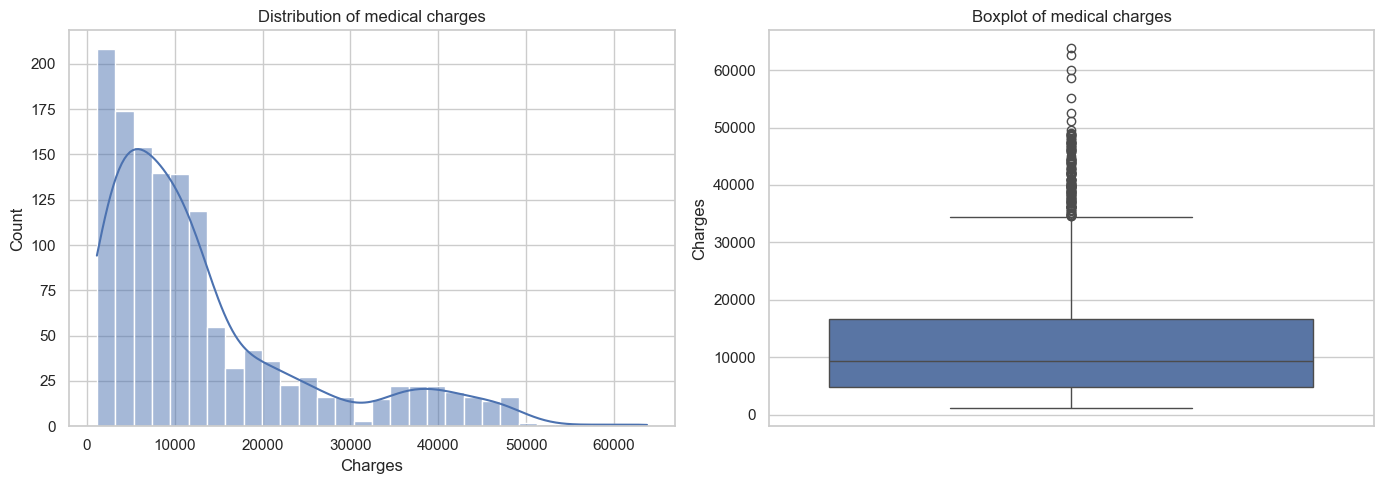

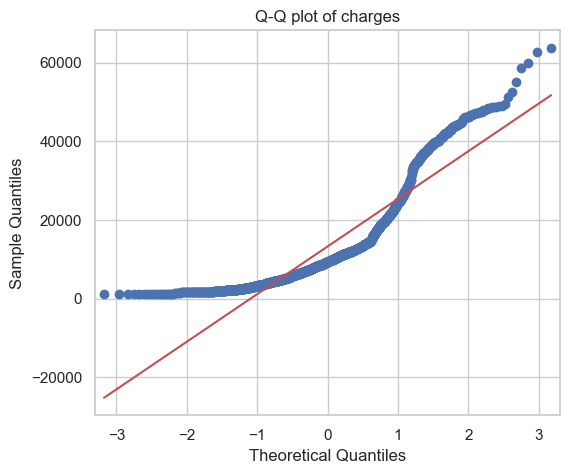

Shapiro-Wilk: W = 0.8147, p-value = 1.1505e-36


In [89]:
# 2.3 - Distribution and normality check for charges

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="charges", kde=True, ax=axes[0])
axes[0].set_title("Distribution of medical charges")
axes[0].set_xlabel("Charges")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, y="charges", ax=axes[1])
axes[1].set_title("Boxplot of medical charges")
axes[1].set_ylabel("Charges")

plt.tight_layout()
plt.show()

# Q-Q plot
fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(df["charges"], line="s", ax=ax)
ax.set_title("Q-Q plot of charges")
plt.show()

# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(df["charges"])
print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4e}")


### 2.3 Results - Normality of `charges`

- Shapiro-Wilk: **W = 0.8147**, **p = 1.15 x 10^-36** -> clearly non-normal.
- The histogram shows strong right skew with a heavy upper tail; the Q-Q plot
  deviates markedly from the reference line above the 75th percentile.
- The boxplot reveals several high-cost outliers well above the upper fence.

> **Note:** in linear regression, the normality assumption applies to **model
> residuals**, not to the raw response. This will be formally tested in
> Section 4.5 after fitting the model.


### 2.4 Categorical composition


In [123]:
# 2.4 — Categorical frequency tables

categorical_cols = ["smoker", "sex", "region"]

for col in categorical_cols:
    print(f"\n=== {col.upper()} ===")
    counts = df[col].value_counts()
    perc   = df[col].value_counts(normalize=True) * 100
    summary = pd.concat([counts, perc], axis=1)
    summary.columns = ["count", "percent"]
    display(summary.round(2))


=== SMOKER ===


,count,percent
smoker,,
no,1064,79.5200
yes,274,20.4800



=== SEX ===


,count,percent
sex,,
male,676,50.5200
female,662,49.4800



=== REGION ===


,count,percent
region,,
southeast,364,27.2000
southwest,325,24.2900
northwest,325,24.2900
northeast,324,24.2200


### 2.4 Results - Categorical composition

| Variable | Category   | n     | %     |
|----------|-----------|------:|------:|
| `smoker` | no        | 1,064 | 79.52 |
|          | yes       |   274 | 20.48 |
| `sex`    | male      |   676 | 50.52 |
|          | female    |   662 | 49.48 |
| `region` | southeast |   364 | 27.20 |
|          | southwest |   325 | 24.29 |
|          | northwest |   325 | 24.29 |
|          | northeast |   324 | 24.22 |

The sample is well balanced by sex and region. Smokers represent about 20% of
the sample - a smaller but financially relevant subgroup, as the next section
will confirm.


### 2.5 Charges by category


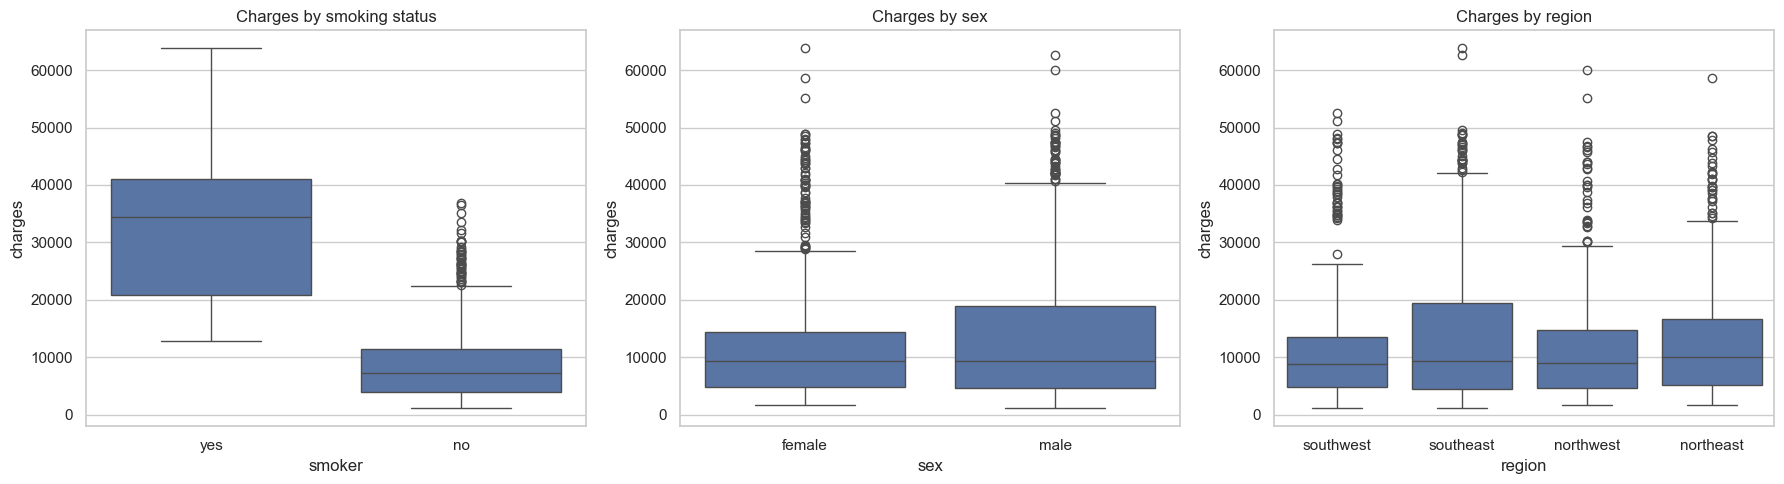

In [147]:
# 2.5 - Boxplots: charges by categorical variables

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
axes[0].set_title("Charges by smoking status")

sns.boxplot(data=df, x="sex", y="charges", ax=axes[1])
axes[1].set_title("Charges by sex")

sns.boxplot(data=df, x="region", y="charges", ax=axes[2])
axes[2].set_title("Charges by region")

plt.tight_layout()
plt.show()


### 2.5 Results - Charges by category

**Smoking status** shows by far the largest contrast:

| Group       | Median charges |
|-------------|---------------:|
| Non-smokers |      7,345.41  |
| Smokers     |     34,456.35  |

Smokers' median is nearly **5x higher** than non-smokers', and the spread of
their distribution is much wider - a pattern fully consistent with the
inferential results in Section 3.

**Sex** differences are negligible: female median = 9,412.96 vs male = 9,369.62.

**Region** shows small differences (northeast highest at ~10k, southwest
lowest at ~8.8k), with largely overlapping distributions.


### 2.6 Correlations and scatterplots - numerical predictors vs `charges`


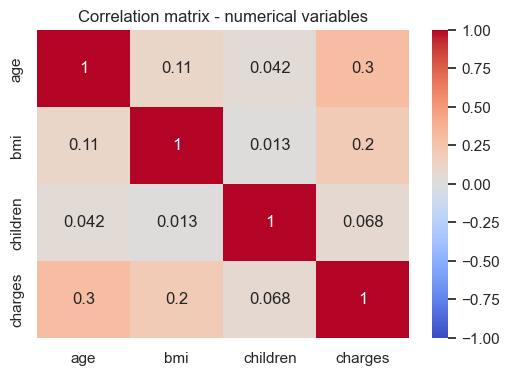

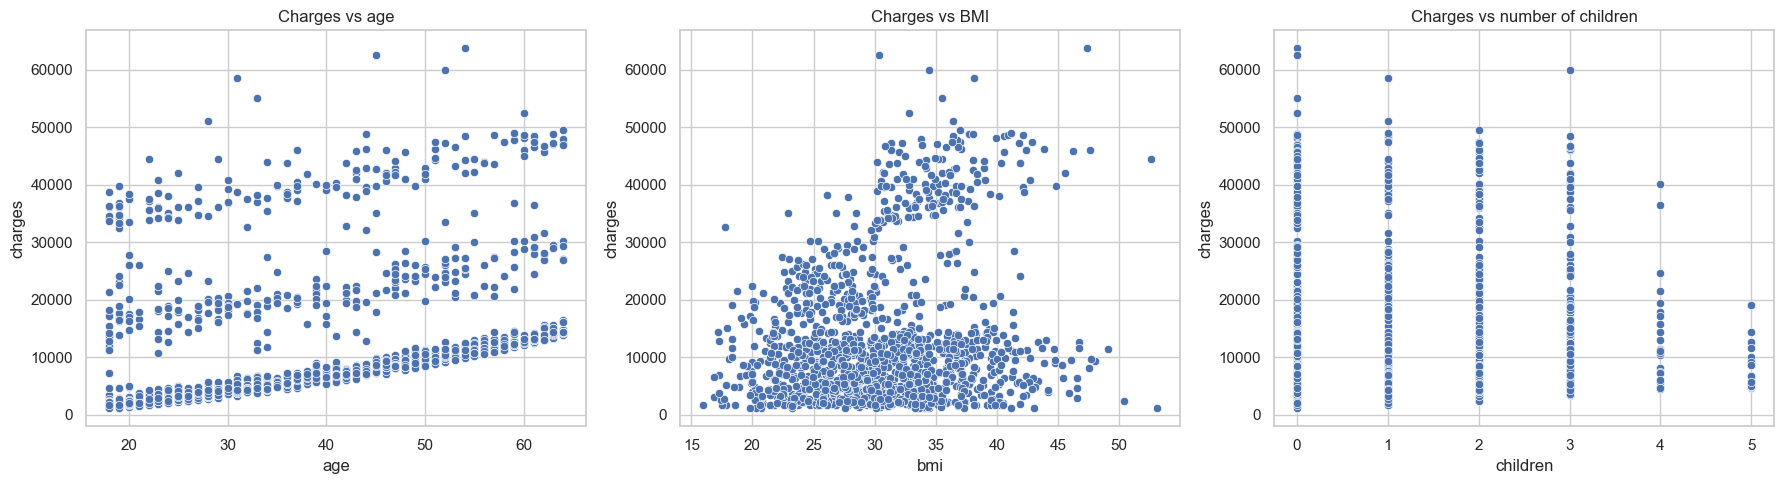

In [170]:
# 2.6 - Correlation matrix + scatterplots

num_cols = ["age", "bmi", "children", "charges"]
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix - numerical variables")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="age", y="charges", ax=axes[0])
axes[0].set_title("Charges vs age")

sns.scatterplot(data=df, x="bmi", y="charges", ax=axes[1])
axes[1].set_title("Charges vs BMI")

sns.scatterplot(data=df, x="children", y="charges", ax=axes[2])
axes[2].set_title("Charges vs number of children")

plt.tight_layout()
plt.show()


### 2.6 Results - Correlations with `charges`

| Predictor  | Pearson r | Interpretation               |
|------------|----------:|------------------------------|
| `age`      |    0.299  | Moderate positive association |
| `bmi`      |    0.198  | Weak-to-moderate positive    |
| `children` |    0.068  | Very weak, no clear pattern  |

- `age` shows the clearest upward trend in the scatter plot, though with
  substantial dispersion - consistent with the moderate correlation.
- `bmi` also trends upward but with considerable noise.
- `children` shows no meaningful linear pattern.

None of the numerical predictors are highly correlated with each other
(max inter-predictor r < 0.15), which is a positive sign for multicollinearity.
This will be confirmed formally via VIF in Section 4.2.


### 2.7 EDA summary

| Finding | Implication for modelling |
|---------|---------------------------|
| `charges` is right-skewed (skewness = 1.52) and heavy-tailed | Residuals may be non-normal; Box-Cox transformation may be needed (Section 4.6) |
| Smoking status drives the largest differences in charges | `smoker` is expected to be the dominant predictor in regression |
| Sex and region differences are small | May not survive significance testing after controlling for other variables |
| No strong inter-predictor correlations | Multicollinearity unlikely; confirmed in Section 4.2 |
| Numerical predictors are well-behaved | No transformation needed for X variables |

**Next step:** Section 3 formally tests the smoking vs non-smoking difference
via Welch's t-test, confidence intervals and effect size measures, before
moving to the full regression model in Section 4.

**Business takeaway:** Smoking status is the strongest early risk-segmentation signal, and age/BMI provide additional structure for pricing analysis.


## 3. Inferential Statistics - Smokers vs Non-Smokers

Business questions:
- Are average medical charges significantly higher for smokers than non-smokers?
- What is the estimated difference in mean charges, with a 95% confidence interval?
- How large is this difference in practical terms (effect size and robustness)?

Analyses:
1. Two-sided Welch t-test for difference in mean charges:
   - H0: mu_smokers = mu_non-smokers
   - H1: mu_smokers != mu_non-smokers
2. 95% confidence intervals for:
   - mean charges in each group
   - the mean difference (smokers - non-smokers)
3. Effect size and robustness:
   - standardized mean difference (Cohen's d, Hedges' g)
   - mean ratio (smokers / non-smokers)
   - non-parametric Mann-Whitney U test
   - bootstrap confidence interval for the mean difference

Concepts applied:
- Central Limit Theorem (CLT) and standard error of the mean
- Welch t-test for independent samples with unequal variances
- Confidence intervals as ranges of plausible values for population means and their difference
- Effect size measures for practical significance
- Robustness checks: rank-based tests (Mann-Whitney) and bootstrap inference


### 3.1 Group statistics: smokers vs non-smokers


In [192]:
# 3.1 - Group statistics: smokers vs non-smokers

smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "no"]["charges"]

n1, n2 = smokers.count(), non_smokers.count()

group_stats = pd.DataFrame({
    "smokers": [
        n1,
        smokers.mean(),
        smokers.median(),
        smokers.std(ddof=1),
        smokers.sem(),
    ],
    "non_smokers": [
        n2,
        non_smokers.mean(),
        non_smokers.median(),
        non_smokers.std(ddof=1),
        non_smokers.sem(),
    ],
}, index=["n", "mean", "median", "std", "sem"])

display(group_stats.round(2))


,smokers,non_smokers
n,274.0000,1064.0000
mean,32050.2300,8434.2700
median,34456.3500,7345.4100
std,11541.5500,5993.7800
sem,697.2500,183.7500


### 3.1 Results - Group statistics and mean difference

**Group statistics for `charges`**

| Metric | Smokers | Non-smokers |
|--------|--------:|------------:|
| n      | 274     | 1,064       |
| Mean   | 32,050.23 | 8,434.27  |
| Median | 34,456.35 | 7,345.41  |
| Std    | 11,541.55 | 5,993.78  |
| SEM    | 697.25    | 183.75    |

Smokers exhibit much higher average and median charges, as well as substantially
greater dispersion. The raw mean difference is about **23,616** in favor of smokers,
anticipating a very large effect to be confirmed formally in the next steps.


### 3.2 Welch's t-test for difference in mean charges


In [213]:
# 3.2 - Welch's t-test for difference in mean charges

t_stat, p_value = ttest_ind(smokers, non_smokers, equal_var=False)

mean_diff = smokers.mean() - non_smokers.mean()

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"p-value (two-sided): {p_value:.4e}")
print()
print(f"Mean difference (smokers - non-smokers): {mean_diff:.2f}")


Welch's t-test statistic: 32.7519
p-value (two-sided): 5.8895e-103

Mean difference (smokers - non-smokers): 23615.96


### 3.2 Results - Welch's t-test

Welch's t-test (two-sided, unequal variances):

- t-statistic = **32.75**
- p-value (two-sided) = **5.89 x 10^-103**
- Mean difference (smokers - non-smokers) = **23,615.96**

The p-value is effectively zero, far below any conventional significance level.
We **reject H0** and conclude that **mean medical charges for smokers and
non-smokers differ substantially** at the population level.


### 3.3 95% confidence intervals for means and mean difference


In [233]:
# 3.3 - 95% confidence intervals for means and mean difference

mean1, mean2 = smokers.mean(), non_smokers.mean()
std1, std2 = smokers.std(ddof=1), non_smokers.std(ddof=1)

se1, se2 = std1 / np.sqrt(n1), std2 / np.sqrt(n2)
alpha = 0.05

# 95% CI for each group mean
df1, df2 = n1 - 1, n2 - 1
t_crit1 = t.ppf(1 - alpha / 2, df1)
t_crit2 = t.ppf(1 - alpha / 2, df2)

ci1_lower = mean1 - t_crit1 * se1
ci1_upper = mean1 + t_crit1 * se1

ci2_lower = mean2 - t_crit2 * se2
ci2_upper = mean2 + t_crit2 * se2

print(f"95% CI for mean charges (smokers):     [{ci1_lower:.2f}, {ci1_upper:.2f}]")
print(f"95% CI for mean charges (non-smokers): [{ci2_lower:.2f}, {ci2_upper:.2f}]")

# 95% CI for difference in means (Welch)
mean_diff = mean1 - mean2
se_diff = np.sqrt(se1**2 + se2**2)

df_welch = (se1**2 + se2**2)**2 / (
    (se1**4) / (n1 - 1) +
    (se2**4) / (n2 - 1)
)

t_crit_diff = t.ppf(1 - alpha / 2, df_welch)

ci_diff_lower = mean_diff - t_crit_diff * se_diff
ci_diff_upper = mean_diff + t_crit_diff * se_diff

print()
print(f"95% CI for mean difference (smokers - non-smokers): [{ci_diff_lower:.2f}, {ci_diff_upper:.2f}]")
print(f"Welch df (approx): {df_welch:.2f}")


95% CI for mean charges (smokers):     [30677.56, 33422.90]
95% CI for mean charges (non-smokers): [8073.71, 8794.82]

95% CI for mean difference (smokers - non-smokers): [22197.21, 25034.71]
Welch df (approx): 311.85


### 3.3 Results - 95% confidence intervals

**Group means**

- Smokers: 95% CI for mu_smokers = **[30,677.56 ; 33,422.90]**
- Non-smokers: 95% CI for mu_non-smokers = **[8,073.71 ; 8,794.82]**

**Mean difference (smokers - non-smokers)**

- Point estimate: **23,615.96**
- 95% CI (Welch) = **[22,197.21 ; 25,034.71]**
- Welch degrees of freedom (approx.) = **311.85**

The entire confidence interval for the mean difference lies well above zero,
indicating that smokers reliably incur **around 22-25k higher** medical charges
on average than non-smokers.


### 3.4 Effect size and practical magnitude


In [250]:
# 3.4 - Effect size and practical magnitude

pooled_sd = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = (mean1 - mean2) / pooled_sd

hedges_g = cohens_d * (1 - 3 / (4 * (n1 + n2) - 9))
mean_ratio = mean1 / mean2

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Hedges' g: {hedges_g:.4f}")
print(f"Mean ratio (smokers / non-smokers): {mean_ratio:.2f}x")


Cohen's d: 3.1613
Hedges' g: 3.1596
Mean ratio (smokers / non-smokers): 3.80x


### 3.4 Results - Effect size

Effect size metrics:

- **Cohen's d** = **3.16**
- **Hedges' g** = **3.16**
- **Mean ratio (smokers / non-smokers)** = **3.80x**

By conventional benchmarks, d > 0.8 is already considered a large effect.
Here, **d ~= 3.16** indicates an **extremely large difference** between smokers
and non-smokers in standardized terms. In business language, smokers generate
on average almost **4 times** the medical charges of non-smokers.


### 3.5 Robustness checks: Mann-Whitney U and bootstrap CI


In [261]:
# 3.5 - Robustness checks: Mann-Whitney U and bootstrap CI

# Mann-Whitney U test (two-sided)
u_stat, u_p = stats.mannwhitneyu(smokers, non_smokers, alternative="two-sided")

print(f"Mann-Whitney U statistic: {u_stat:.0f}")
print(f"p-value (two-sided): {u_p:.4e}")

# Bootstrap CI for mean difference
rng = np.random.default_rng(42)
B = 5000

s1 = smokers.to_numpy()
s2 = non_smokers.to_numpy()

boot_mean_diff = np.empty(B)
for i in range(B):
    boot_s1 = rng.choice(s1, size=n1, replace=True)
    boot_s2 = rng.choice(s2, size=n2, replace=True)
    boot_mean_diff[i] = boot_s1.mean() - boot_s2.mean()

boot_ci_lower, boot_ci_upper = np.percentile(boot_mean_diff, [2.5, 97.5])
print()
print(f"Bootstrap 95% CI for mean difference: [{boot_ci_lower:.2f}, {boot_ci_upper:.2f}]")


Mann-Whitney U statistic: 284133
p-value (two-sided): 5.2702e-130

Bootstrap 95% CI for mean difference: [22217.37, 25012.66]


### 3.5 Results - Robustness checks

**Mann-Whitney U test (non-parametric)**

- U statistic = **284,133**
- p-value (two-sided) = **5.27 x 10^-130**

The Mann-Whitney test, which compares the distributions via ranks without
assuming normality, again yields an essentially zero p-value. This confirms
that the **distribution** of charges for smokers is systematically shifted
upward relative to non-smokers.

**Bootstrap 95% CI for the mean difference**

- Bootstrap 95% CI (smokers - non-smokers) = **[22,217.37 ; 25,012.66]**

The bootstrap interval is very close to the analytical Welch CI, indicating
that the estimated mean difference of approximately 23.6k is highly robust to distributional
assumptions and outliers.


### 3.6 Summary - Inferential results for smokers vs non-smokers

- Smokers have **much higher average medical charges** than non-smokers:
  the mean difference is about **US$ 23.6k**, with a 95% CI roughly
  **[22.2k ; 25.0k]**.
- The effect is **statistically overwhelming** (p-value approximately 0 in both Welch
  t-test and Mann-Whitney) and **practically huge** (Cohen's d approximately 3.16;
  mean ratio approximately 3.8x).
- Parametric (Welch), non-parametric (Mann-Whitney) and bootstrap methods
  all point to the same conclusion, providing strong evidence that smoking
  is a major driver of medical costs in this dataset.

These inferential results justify treating `smoker` as a **central predictor**
in the multiple regression models of Section 4, both for explanatory analysis
and for potential risk-based pricing strategies in an insurance context.

**Business takeaway:** The smoker surcharge signal is statistically robust and economically large, supporting differentiated risk-based pricing.


## 4. Modelling Strategy - Multiple Linear Regression

From this point on, the focus shifts from exploratory and inferential analysis
to **predictive modelling** of medical charges using linear regression.

Workflow:

1. Define target and predictors and encode categorical variables.
2. Check multicollinearity via VIF.
3. Fit a **full multiple OLS model** and interpret coefficients.
4. Use **backward elimination** to obtain a parsimonious reduced model.
5. Diagnose residuals and apply a **Box-Cox transformation** to the response.
6. Test for **heteroscedasticity** (Breusch-Pagan) and correct inference via **HC3**.

This pipeline balances interpretability, statistical rigour and readiness for
validation (train/test and cross-validation in the next section).


### 4.1 Target and predictors


In [278]:
# 4.1 - Define target and predictors
y = df["charges"]

X = df[["age", "bmi", "children", "smoker", "sex", "region"]]
X = pd.get_dummies(X, drop_first=True, dtype=float)  # reference: smoker=no, sex=female, region=northeast


### 4.1 Results - Target and predictors

- **Target (Y):** `charges` (continuous).
- **Predictors (X):** `age`, `bmi`, `children`, `smoker`, `sex`, `region`.
- Categorical variables are encoded with `drop_first=True`, so the reference
  categories are:
  - `smoker = "no"`, `sex = "female"`, `region = "northeast"`.

All regression coefficients will therefore be interpreted **relative to these
reference groups**, holding the other variables constant.


### 4.2 Multicollinearity check - Variance Inflation Factor (VIF)


In [294]:
# 4.2 - VIF to check multicollinearity
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    "feature": X_with_const.columns,
    "VIF": [
        variance_inflation_factor(X_with_const.values, i)
        for i in range(X_with_const.shape[1])
    ],
})

display(vif_data.round(2))


,feature,VIF
0,const,35.5300
1,age,1.0200
2,bmi,1.1100
3,children,1.0000
4,smoker_yes,1.0100
5,sex_male,1.0100
6,region_northwest,1.5200
7,region_southeast,1.6500
8,region_southwest,1.5300


### 4.2 Results - Multicollinearity (VIF)

- All predictors (`age`, `bmi`, `children`, `smoker_yes`, `sex_male`,
  region dummies) have **VIF ~= 1.0-1.2**.
- Only the intercept shows a high VIF, which is expected and not a concern,
  since it is not a predictor of interest.

As a rule of thumb, VIF values above 5-10 would indicate problematic
multicollinearity. Here, **all explanatory variables have VIF close to 1**,
so there is **no evidence of harmful multicollinearity**, and we can safely
interpret the coefficients.


### 4.3 Full OLS model - `charges ~ age + bmi + children + smoker + sex + region`


In [300]:
# 4.3 - Full OLS model

X_const = sm.add_constant(X)
ols_full = sm.OLS(y, X_const).fit()
print(ols_full.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:34:55   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

### 4.3 Results - Full multiple linear regression

**Overall fit**

- R^2 = **0.751**, Adjusted R^2 = **0.749**.
- The model explains about **75% of the variability** in medical charges,
  which is high for real-world cost data.
- The global F-test is highly significant (F ~= 500.8, p < 0.001), indicating
  that the predictors jointly have strong explanatory power.

**Key coefficients (ceteris paribus effects)**

- **Age (`age`, ~= 257, p < 0.001)**  
  Each additional year of age is associated with about **US$ 257** higher
  expected charges, holding other variables constant.

- **BMI (`bmi`, ~= 339, p < 0.001)**  
  Each 1-unit increase in BMI is associated with roughly **US$ 339** higher
  charges on average; a 5-point BMI difference implies ~= **US$ 1.7k** extra cost.

- **Children (`children`, ~= 476, p ~= 0.001)**  
  Each additional child is associated with ~= **US$ 476** higher charges on average,
  controlling for the other predictors.

- **Smoking (`smoker_yes`, ~= 23,850, p < 0.001)**  
  After controlling for age, BMI, children, sex and region, smokers have on
  average **~= US$ 23.9k higher** medical charges than non-smokers, confirming
  the huge effect found in Section 3.

- **Sex (`sex_male`, p ~= 0.69)**  
  Once other factors are controlled, there is **no statistically significant
  difference** in charges between males and females.

- **Region (reference: northeast)**  
  Southeast and southwest show modestly **lower** charges (~= US$ 1k) relative
  to the northeast; northwest is not significantly different.

The full model reveals that **age, BMI, number of children and especially
smoking status** are the main drivers of medical charges, while sex and some
regional effects are weak once other covariates are included.


### 4.4 Model selection - Backward Elimination


In [314]:
# 4.4 - Backward elimination via stepwise (p-value based, alpha = 0.05)

ols_reduced = stepwise(ols_full, pvalue_limit=0.05)
print(ols_reduced.summary())

# Full vs reduced model comparison
comparison = pd.DataFrame(
    {
        "Full model": [ols_full.rsquared, ols_full.rsquared_adj, ols_full.aic, ols_full.bic],
        "Reduced model": [ols_reduced.rsquared, ols_reduced.rsquared_adj, ols_reduced.aic, ols_reduced.bic],
    },
    index=["R^2", "Adjusted R^2", "AIC", "BIC"],
)

display(comparison.round(4))


Regression type: OLS 

Estimating model...: 
 charges ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('sex_male') + Q('region_northwest') + Q('region_southeast') + Q('region_southwest')

 Discarding atribute "Q('sex_male')" with p-value equal to 0.693347519159965 

Estimating model...: 
 charges ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('region_northwest') + Q('region_southeast') + Q('region_southwest')

 Discarding atribute "Q('region_northwest')" with p-value equal to 0.45961790931944413 

Estimating model...: 
 charges ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('region_southeast') + Q('region_southwest')

 Discarding atribute "Q('region_southwest')" with p-value equal to 0.058733990443848146 

Estimating model...: 
 charges ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('region_southeast')

 Discarding atribute "Q('region_southeast')" with p-value equal to 0.136346417800076 

Estimating model...: 
 charges ~ Q('age') + Q('b

,Full model,Reduced model
R^2,0.7509,0.7497
Adjusted R^2,0.7494,0.7489
AIC,27113.5058,27112.0352
BIC,27160.2962,27138.0299


### 4.4 Results - Backward elimination (reduced OLS model)

The stepwise procedure (`pvalue_limit = 0.05`) starting from the full model
removed the non-significant predictors and produced a reduced specification
in which all remaining coefficients are statistically significant at the 5%
level.

**Full vs reduced model**

| Metric      | Full model | Reduced model |
|-------------|-----------:|--------------:|
| R^2         | 0.7509     | 0.7497        |
| Adjusted R^2| 0.7494     | 0.7489        |
| AIC         | 27,113.51  | 27,112.04     |
| BIC         | 27,160.30  | 27,138.03     |

- R^2 and adjusted R^2 decrease only **marginally**, so explanatory power is
  essentially preserved.
- **AIC** and **BIC** are slightly **lower** in the reduced model, favouring
  the simpler specification.

The reduced OLS model is therefore adopted as the **reference specification**
on the original `charges` scale for diagnostic analysis and validation.


### 4.4.1 Diagnostic plot - Actual vs Predicted (reduced model)


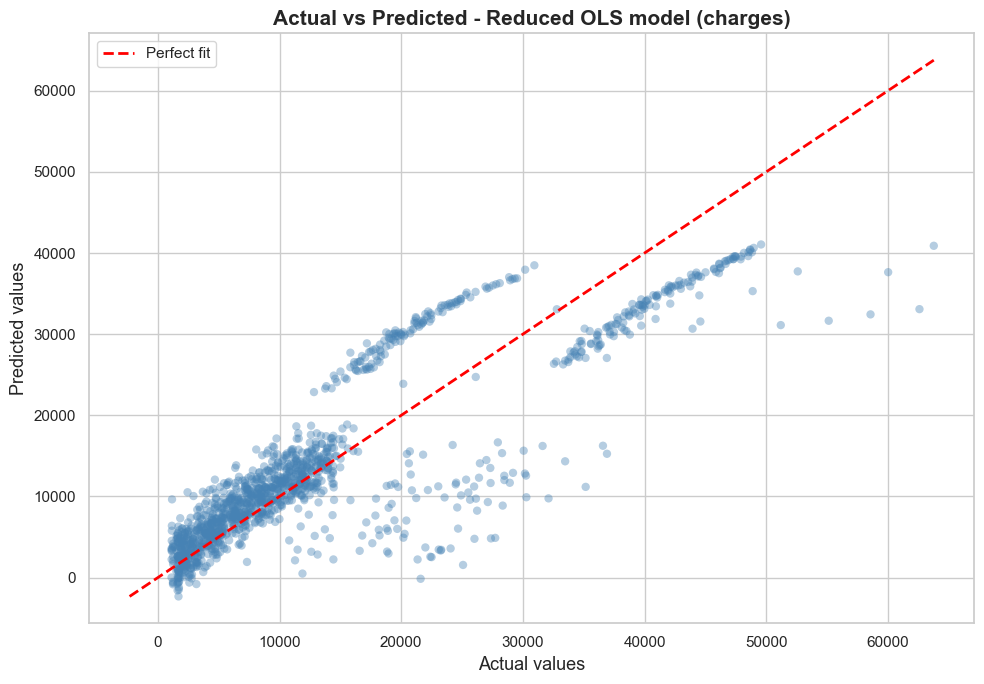

In [327]:
# 4.4.1 - Diagnostic plot helper (Actual vs Predicted)

def diagnostic_plots(model, y_true, title):
    # Scatter plot: Actual vs Predicted values.
    # Points close to the 45-degree line indicate good model fit.
    y_pred = model.fittedvalues

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(y_true, y_pred, alpha=0.4, color="steelblue", edgecolors="none")

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect fit")

    ax.set_xlabel("Actual values", fontsize=13)
    ax.set_ylabel("Predicted values", fontsize=13)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Diagnostics - Reduced OLS model (charges)
diagnostic_plots(
    model=ols_reduced,
    y_true=y,
    title="Actual vs Predicted - Reduced OLS model (charges)",
)


### 4.4.1 Results — Actual vs Predicted (reduced OLS model)

The **Actual vs Predicted** plot for the reduced OLS model shows a strong,
roughly linear relationship: most points lie in a band near the 45‑degree
reference line, consistent with the high in‑sample R² ≈ 0.75.

At the same time, the cloud is clearly **structured in bands rather than a
single homogeneous cloud**: three almost parallel curves appear, reflecting
the dominant discrete effect of smoking status combined with BMI — a lower‑cost
band of non‑smokers and two higher‑cost bands of smokers with different BMI
profiles. Within each band, the model tracks charges reasonably well.

For low and moderate charges (up to ≈ 20–25k), prediction errors are relatively
small. For high‑cost individuals (above ≈ 30–40k), points deviate further from
the line and predicted values tend to **under‑estimate** the most expensive
cases, never reaching the very highest observed charges. This pattern is
consistent with the heteroscedastic and right‑skewed residuals detected in the
subsequent diagnostics.

### 4.5 Normality of residuals - Shapiro-Francia test


method  :  Shapiro-Francia normality test
statistics W  :  0.8994480100701633
statistics z  :  10.443353114245292
p-value  :  7.85797015618757e-26
Statistics W=0.89945, p-value=0.000000
Reject H0 - residuals are not normally distributed


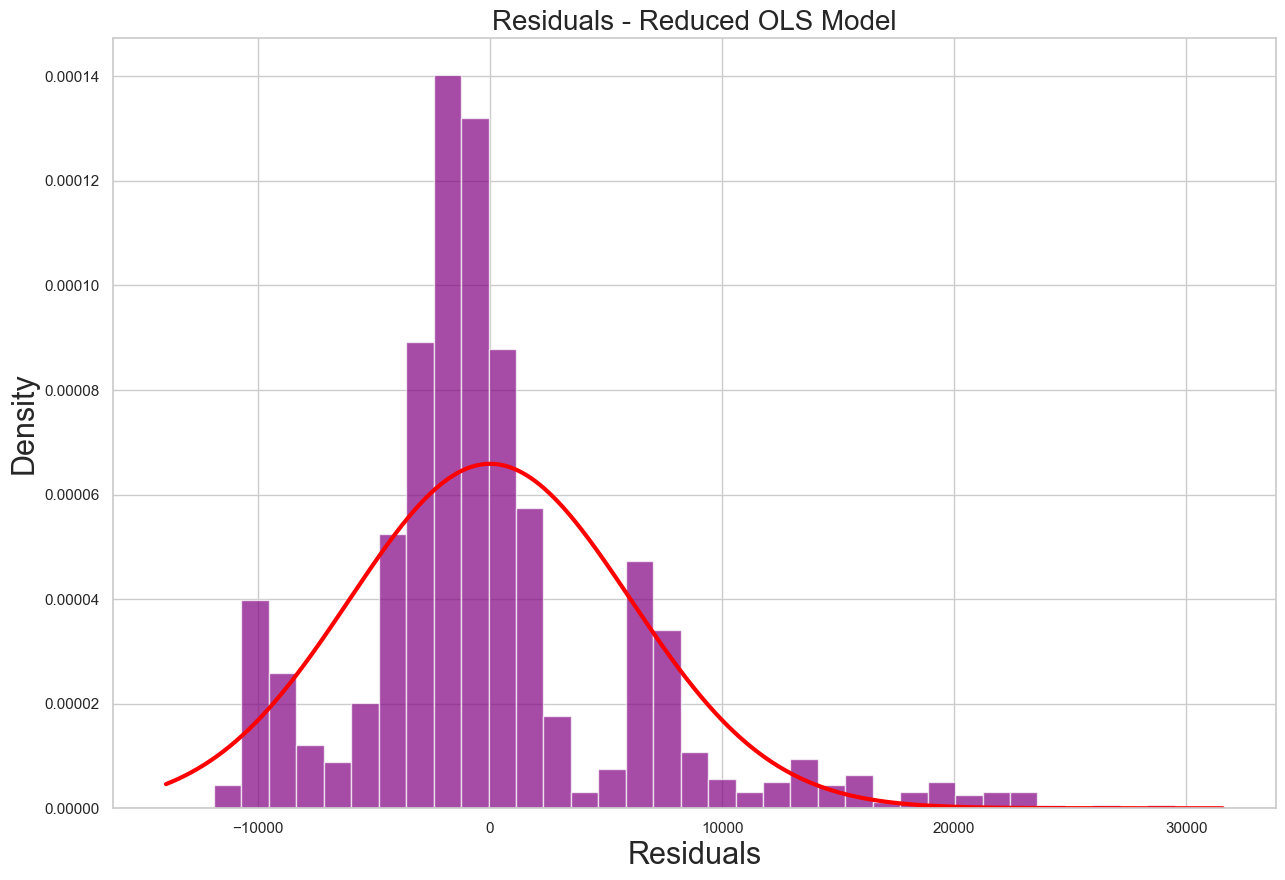

In [339]:
# 4.5 - Normality of residuals: Shapiro-Francia test + histogram

teste_sf = shapiro_francia(ols_reduced.resid)
teste_sf = teste_sf.items()
method, statistics_W, statistics_z, p = teste_sf

print("Statistics W=%.5f, p-value=%.6f" % (statistics_W[1], p[1]))

alpha = 0.05
if p[1] > alpha:
    print("Fail to reject H0 - residuals are normally distributed")
else:
    print("Reject H0 - residuals are not normally distributed")

# Histogram of residuals vs fitted normal curve
mu, std = norm.fit(ols_reduced.resid)

plt.figure(figsize=(15, 10))
plt.hist(ols_reduced.resid, bins=35, density=True, alpha=0.7, color="purple")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 1000)
plt.plot(x, norm.pdf(x, mu, std), linewidth=3, color="red")
plt.title("Residuals - Reduced OLS Model", fontsize=20)
plt.xlabel("Residuals", fontsize=22)
plt.ylabel("Density", fontsize=22)
plt.show()


### 4.5 Results - Normality of residuals (reduced model)

- Shapiro-Francia on residuals: **W = 0.89945**, **p ~= 7.86 x 10^-26**.
- We **reject H0** and conclude that residuals are **not normally distributed**.

The histogram confirms a right-skewed, heavy-tailed shape, reflecting the
asymmetry of the underlying `charges` distribution. This motivates trying a
**Box-Cox transformation** of the response variable to obtain a more
well-behaved error distribution.


### 4.6 Box-Cox transformation and respecified model


In [347]:
# 4.6.1 - Box-Cox transformation of the response variable
charges_bc, lmbda = boxcox(df["charges"])
print(f"Optimal lambda (lambda): {lmbda:.4f}")
df["charges_bc"] = charges_bc


Optimal lambda (lambda): 0.0436


### 4.6.1 Results - Optimal lambda

The estimated Box-Cox parameter is **lambda = 0.0436**, very close to zero.
This is almost equivalent to a **log transformation** and is consistent with
the strong right skew observed for `charges` in Section 2, suggesting an
approximately log-normal pattern for medical costs.


### 4.6.2 Box-Cox respecified model - stepwise, normality and fit diagnostics


  BOX–COX MODEL — stepwise (λ = 0.0436)
Regression type: OLS 

Estimating model...: 
 charges_bc ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('sex_male') + Q('region_northwest') + Q('region_southeast') + Q('region_southwest')

 Discarding atribute "Q('region_northwest')" with p-value equal to 0.0720391929032995 

Estimating model...: 
 charges_bc ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('sex_male') + Q('region_southeast') + Q('region_southwest')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('region_northwest')", 'p-value': np.float64(0.0720391929032995)}

 Model after stepwise process...: 
 charges_bc ~ Q('age') + Q('bmi') + Q('children') + Q('smoker_yes') + Q('sex_male') + Q('region_southeast') + Q('region_southwest') 

                            OLS Regression Results                            
Dep. Variable:             charges_bc   R-squared:                       0.770
Model:        

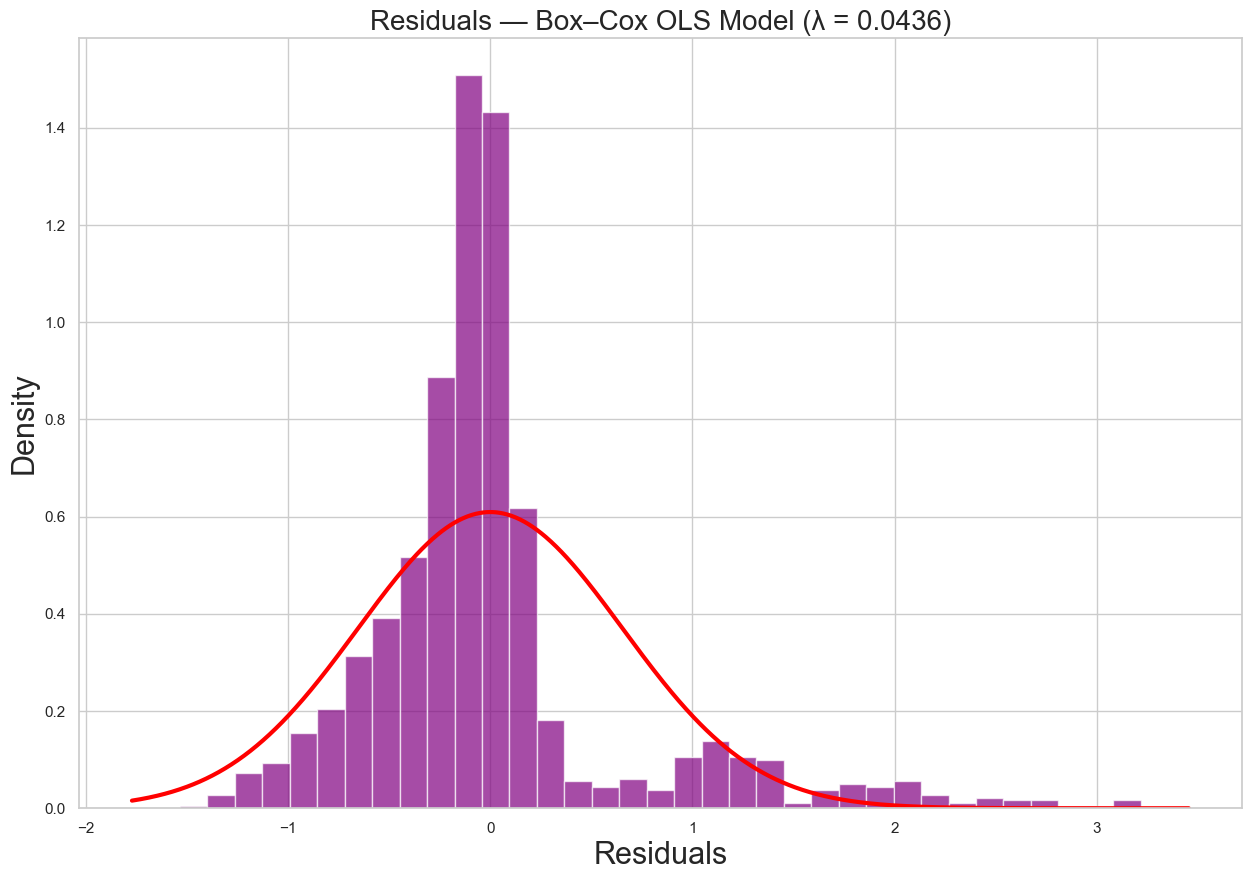

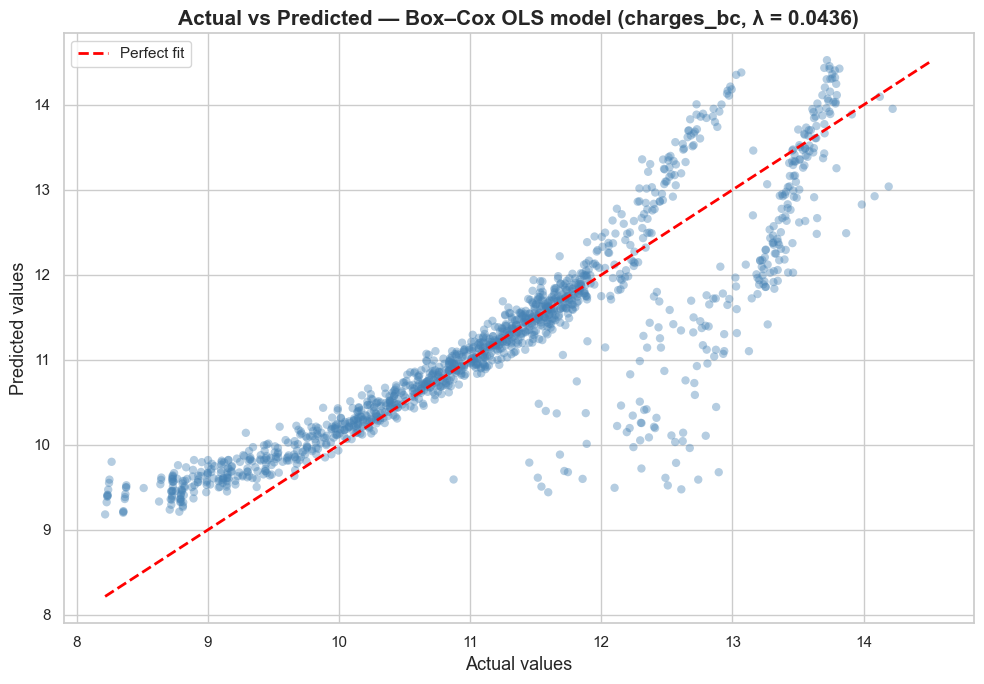

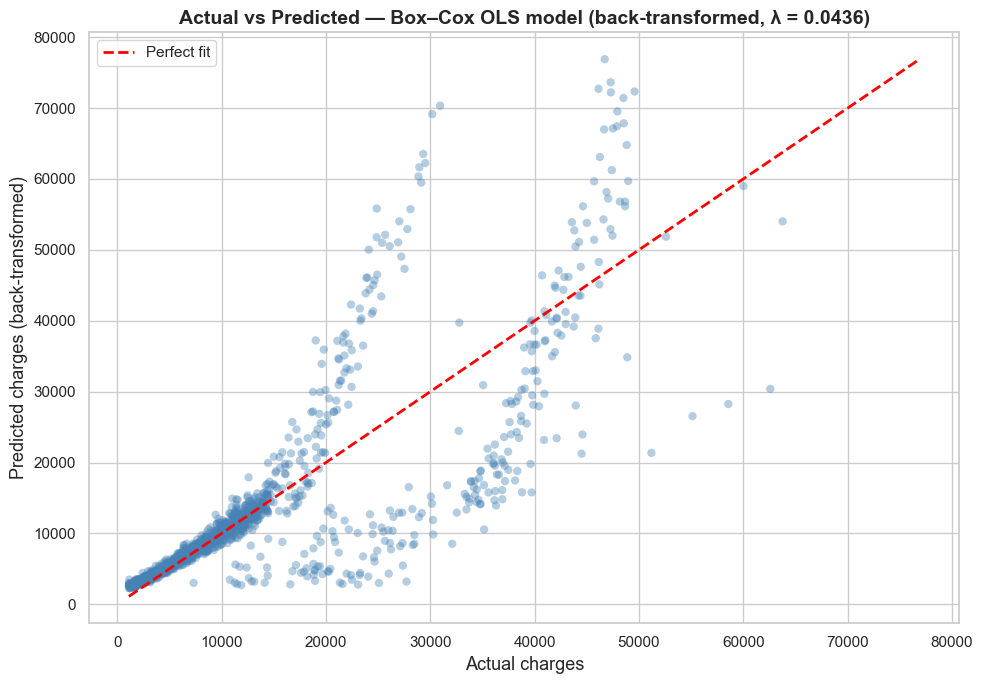

In [357]:
# 4.6.2 — Refit OLS with transformed response + stepwise + normality check

y_bc = df["charges_bc"]
X_const = sm.add_constant(X)
ols_bc_full = sm.OLS(y_bc, X_const).fit()

# Stepwise selection
print("=" * 60)
print(f"  BOX–COX MODEL — stepwise (λ = {lmbda:.4f})")
print("=" * 60)
ols_bc = stepwise(ols_bc_full, pvalue_limit=0.05)
print(ols_bc.summary())

# Shapiro–Francia on Box–Cox residuals
print("\n" + "=" * 60)
print("  SHAPIRO–FRANCIA — normality of residuals (Box–Cox model)")
print("=" * 60)
teste_sf_bc = shapiro_francia(ols_bc.resid)
teste_sf_bc = teste_sf_bc.items()
method, statistics_W, statistics_z, p = teste_sf_bc
print("  Statistics W=%.5f, p-value=%.6f" % (statistics_W[1], p[1]))
if p[1] > 0.05:
    print("  Fail to reject H0 — residuals are normally distributed")
else:
    print("  Reject H0 — residuals are not normally distributed")

# Histogram of Box–Cox residuals
mu, std = norm.fit(ols_bc.resid)

plt.figure(figsize=(15, 10))
plt.hist(ols_bc.resid, bins=35, density=True, alpha=0.7, color="purple")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 1000)
plt.plot(x, norm.pdf(x, mu, std), linewidth=3, color="red")
plt.title(f"Residuals — Box–Cox OLS Model (λ = {lmbda:.4f})", fontsize=20)
plt.xlabel("Residuals", fontsize=22)
plt.ylabel("Density", fontsize=22)
plt.show()

# Diagnostics — Box–Cox OLS model on transformed scale
diagnostic_plots(
    model=ols_bc,
    y_true=y_bc,
    title=f"Actual vs Predicted — Box–Cox OLS model (charges_bc, λ = {lmbda:.4f})",
)

# Back-transform: fitted and actual values to original scale
# Inverse Box–Cox: y = (λ * y_bc + 1)^(1/λ)
y_true_orig = np.power(lmbda * y_bc.values + 1, 1 / lmbda)
y_pred_orig = np.power(lmbda * ols_bc.fittedvalues + 1, 1 / lmbda)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(y_true_orig, y_pred_orig, alpha=0.4, color="steelblue", edgecolors="none")
lims = [min(y_true_orig.min(), y_pred_orig.min()), max(y_true_orig.max(), y_pred_orig.max())]
ax.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect fit")
ax.set_xlabel("Actual charges", fontsize=13)
ax.set_ylabel("Predicted charges (back-transformed)", fontsize=13)
ax.set_title(
    f"Actual vs Predicted — Box–Cox OLS model (back-transformed, λ = {lmbda:.4f})",
    fontsize=14,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

### 4.6.2 Results - Box-Cox respecified model

**Model and selection**

- Stepwise removes only `region_northwest` (p ~= 0.072); all remaining predictors
  are significant.
- The final Box-Cox model achieves **R^2 = 0.770** and **Adj. R^2 = 0.769**,
  slightly higher than the reduced model on `charges` (0.7497 / 0.7489).
- `sex_male` becomes statistically significant here (p ~= 0.003), revealing a
  small but non-zero sex effect on the transformed scale.

**Residual normality**

- Shapiro-Francia on Box-Cox residuals: **W = 0.82935**, **p ~= 8.21 x 10^-32**.
- We still **reject H0**; residuals remain non-normal, though the transformation
  reduces skewness compared to the original model.

**Actual vs Predicted - transformed scale (`charges_bc`)**

The **Actual vs Predicted** plot in the transformed scale shows a tight,
near-linear alignment around the 45-degree line, with no obvious curvature
or systematic bias. This indicates that the **linear specification is
well-behaved in the model's native Box-Cox space.**

**Actual vs Predicted - original scale (back-transformed)**

When we back-transform fitted and actual values to the original `charges`
scale, the plot changes shape:

- For low and medium charges, points cluster close to the 45-degree line.
- For high-cost individuals (~= 30-40k and above), the cloud fans out markedly,
  with both over- and under-estimation.

This is expected: the inverse Box-Cox is **non-linear**, so small residuals in
`charges_bc` become **large absolute errors** in `charges`, especially in the
upper tail. The model is still reasonable, but predicting very expensive
patients remains intrinsically difficult.

**Takeaway**

The Box-Cox re-specification offers a modest improvement in fit and slightly
different coefficient structure, but does **not fully restore normality** nor
eliminate prediction challenges in the upper tail. It is best interpreted as a
**robustness check** alongside the reduced OLS model on the original scale.


### 4.7 Homoscedasticity - Breusch-Pagan test


In [361]:
# 4.7 — Breusch–Pagan test for homoscedasticity

def breusch_pagan_test(modelo):
    df_bp = pd.DataFrame({"yhat": modelo.fittedvalues, "resid": modelo.resid})
    df_bp["up"] = (df_bp.resid**2) / np.sum((df_bp.resid**2) / df_bp.shape[0])

    modelo_aux = sm.OLS.from_formula("up ~ yhat", df_bp).fit()
    anova_table = sm.stats.anova_lm(modelo_aux, typ=2)
    anova_table["sum_sq"] = anova_table["sum_sq"] / 2

    chisq = anova_table["sum_sq"].iloc[0]
    p_value = stats.chi2.pdf(chisq, 1) * 2
    return chisq, p_value

alpha = 0.05

print("=" * 60)
print("  BREUSCH–PAGAN — Reduced OLS model (charges)")
print("=" * 60)
bp_reduced = breusch_pagan_test(ols_reduced)
print(f"  chi²: {bp_reduced[0]:.4f}")
print(f"  p-value: {bp_reduced[1]:.6f}")
print("  " + ("Fail to reject H0 — No heteroscedasticity" if bp_reduced[1] > alpha else "Reject H0 — Heteroscedasticity detected"))

print("\n" + "=" * 60)
print("  BREUSCH–PAGAN — Box–Cox OLS model (charges_bc)")
print("=" * 60)
bp_bc = breusch_pagan_test(ols_bc)
print(f"  chi²: {bp_bc[0]:.4f}")
print(f"  p-value: {bp_bc[1]:.6f}")
print("  " + ("Fail to reject H0 — No heteroscedasticity" if bp_bc[1] > alpha else "Reject H0 — Heteroscedasticity detected"))

  BREUSCH–PAGAN — Reduced OLS model (charges)
  chi²: 230.5625
  p-value: 0.000000
  Reject H0 — Heteroscedasticity detected

  BREUSCH–PAGAN — Box–Cox OLS model (charges_bc)
  chi²: 47.6299
  p-value: 0.000000
  Reject H0 — Heteroscedasticity detected


### 4.7 Results - Breusch-Pagan test

- **Reduced OLS model (charges)**  
  - chi^2 ~= **230.56**, p-value ~= **0.000000** -> **Reject H0**: strong evidence of heteroscedasticity.

- **Box-Cox model (charges_bc)**  
  - chi^2 ~= **47.63**, p-value ~= **0.000000** -> **Reject H0** again: heteroscedasticity persists,
    though the statistic is much smaller.

Interpretation:

- The Box-Cox transformation **reduces** the severity of heteroscedasticity,
  but does not remove it.
- OLS coefficient estimates remain unbiased, but **classical standard errors
  are no longer trustworthy**, so we adopt **heteroscedasticity-robust
  standard errors (HC3)** for inference.


### 4.8 Heteroscedasticity-consistent standard errors (HC3)


In [369]:
# 4.8 — Models with heteroscedasticity-consistent SE (HC3)

ols_reduced_hc3 = ols_reduced.get_robustcov_results(cov_type="HC3")
print("=" * 60)
print("  REDUCED OLS MODEL (charges) — HC3 standard errors")
print("=" * 60)
print(ols_reduced_hc3.summary())

ols_bc_hc3 = ols_bc.get_robustcov_results(cov_type="HC3")
print("\n" + "=" * 60)
print("  BOX–COX OLS MODEL (charges_bc) — HC3 standard errors")
print("=" * 60)
print(ols_bc_hc3.summary())

  REDUCED OLS MODEL (charges) — HC3 standard errors
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     595.1
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          1.17e-294
Time:                        20:36:03   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

### 4.8 Results - HC3 robust inference

Applying **HC3** to both models leads to the expected pattern:

- **Point estimates remain unchanged** relative to the standard OLS output.
- **Standard errors increase slightly**, yielding more conservative t-statistics
  and p-values.
- All key predictors - age, BMI, number of children and especially
  `smoker_yes` - remain **highly significant** in both the reduced and
  Box-Cox specifications.

Because HC3 only affects the **variance-covariance matrix**, fitted values and
residuals are identical to those used in the diagnostic plots above. Combining
the Breusch-Pagan evidence of heteroscedasticity with HC3 robust standard
errors ensures that our coefficient inference is **reliable**, while keeping
the linear regression framework intact.

In the next section, we evaluate **out-of-sample performance** (train/test split
and k-fold cross-validation) using these models as our reference specifications.

**Business takeaway:** Core pricing drivers remain stable under robust inference, so decisions can focus on age, BMI, children and smoking with higher confidence.


## 5. Validation - Train/Test Split and Cross-Validation

Up to this point, modelling steps in Sections 3 and 4 focused on in-sample
fit, interpretation and diagnostics. In this section, we switch to
**out-of-sample validation**.

Main principles used here:

1. Perform **train/test split first** and keep the test set untouched.
2. Run **backward elimination on training data only** to avoid leakage.
3. Compare the reduced model against a **naive baseline** (`DummyRegressor`).
4. Evaluate with multiple metrics: **R2, RMSE and MAE**.
5. Use **RepeatedKFold (10 x 5)** for more stable cross-validation estimates.

This makes performance claims more robust and closer to real deployment
conditions.


### 5.1 Train/test split (80/20) using the reduced OLS specification


In [376]:
# 5.1 - Train/test split (80/20) + train-only feature selection
# 1) Split first to avoid leakage
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
# 2) Backward elimination on TRAIN only
def backward_elimination_train(X_train_df, y_train_series, alpha=0.05):
    selected = list(X_train_df.columns)
    while True:
        model_tmp = sm.OLS(
            y_train_series,
            sm.add_constant(X_train_df[selected], has_constant="add")
        ).fit()
        pvals = model_tmp.pvalues.drop("const", errors="ignore")
        worst_p = pvals.max()
        if worst_p <= alpha:
            break
        worst_feature = pvals.idxmax()
        selected.remove(worst_feature)
        if len(selected) == 0:
            break
    final_model = sm.OLS(
        y_train_series,
        sm.add_constant(X_train_df[selected], has_constant="add")
    ).fit()
    return final_model, selected
ols_reduced_train, selected_features_train = backward_elimination_train(
    X_train_full, y_train, alpha=0.05
)
# 3) Fit reduced linear model (scikit-learn) using selected features
X_train = X_train_full[selected_features_train]
X_test = X_test_full[selected_features_train]
linreg_reduced = LinearRegression()
linreg_reduced.fit(X_train, y_train)
y_train_pred = linreg_reduced.predict(X_train)
y_test_pred = linreg_reduced.predict(X_test)
# 4) Baseline model (predict train mean)
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_train_pred_base = baseline.predict(X_train)
y_test_pred_base = baseline.predict(X_test)
# 5) Metrics helper
def compute_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }
rows = []
for model_name, pred_train, pred_test in [
    ("Reduced model", y_train_pred, y_test_pred),
    ("Baseline (mean)", y_train_pred_base, y_test_pred_base),
]:
    train_m = compute_metrics(y_train, pred_train)
    test_m = compute_metrics(y_test, pred_test)
    rows.append({"Model": model_name, "Split": "Train", **train_m})
    rows.append({"Model": model_name, "Split": "Test", **test_m})
metrics_train_test = pd.DataFrame(rows).set_index(["Model", "Split"])
print("Selected features from TRAIN-only stepwise:")
print(selected_features_train)
display(metrics_train_test.round(4))


Selected features from TRAIN-only stepwise:
['age', 'bmi', 'children', 'smoker_yes']


R2       RMSE       MAE
Model           Split                             
Reduced model   Train  0.7411  6113.0678 4210.6641
                Test   0.7811  5829.3785 4213.7986
Baseline (mean) Train  0.0000 12013.8929 9000.5561
                Test  -0.0009 12465.6104 9593.3385

### 5.1 Results - Leak-safe train/test validation + baseline comparison

This split is now **methodologically stricter**:

- Feature selection (backward elimination) is done on **training data only**.
- The 20% test set remains untouched until final scoring.
- Performance is benchmarked against a naive **mean baseline**.

How to read the output table:

- A good model should beat baseline on the **test split** for all metrics.
- We want **higher R2** and **lower RMSE/MAE** than baseline.
- A small train-vs-test gap indicates good generalization and low overfitting.

In this project, the reduced model should clearly outperform the baseline,
while still showing larger absolute errors in the high-cost tail.


### 5.1.1 Actual vs Predicted: test set (20%)


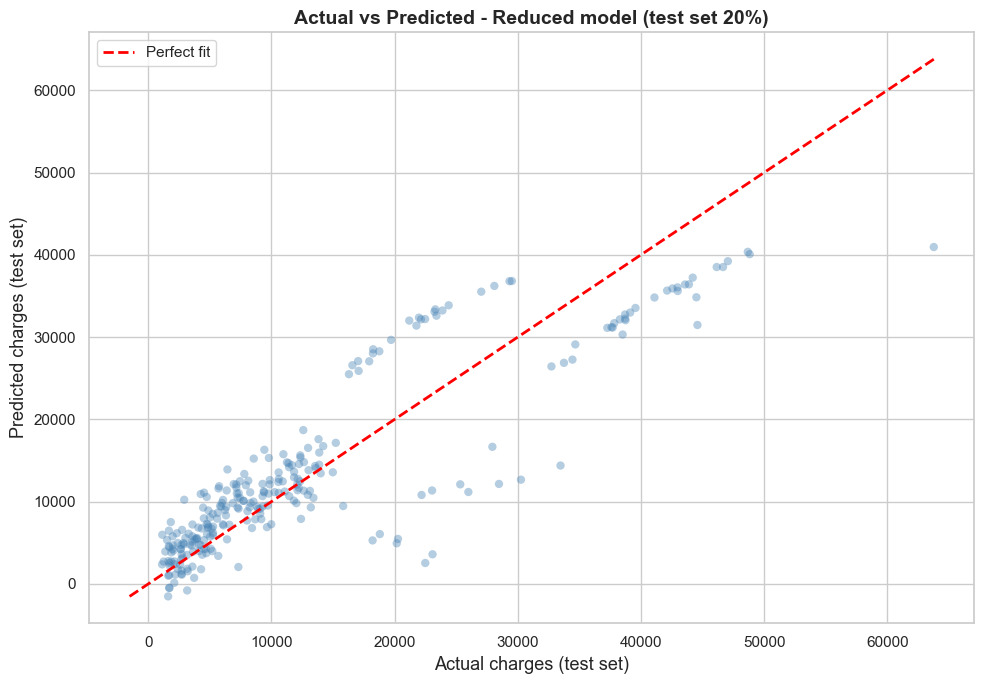

In [382]:
# 5.1.1 - Actual vs Predicted: test set (20%)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_test, y_test_pred, alpha=0.4, color="steelblue", edgecolors="none")

# 45-degree line (perfect fit)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect fit")

ax.set_xlabel("Actual charges (test set)", fontsize=13)
ax.set_ylabel("Predicted charges (test set)", fontsize=13)
ax.set_title("Actual vs Predicted - Reduced model (test set 20%)", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()


### 5.1.1 Results - Actual vs Predicted (test set 20%)

The hold-out scatter should remain close to the 45-degree line for most
low-to-mid cost individuals, confirming useful out-of-sample fit.

As expected in this dataset, dispersion increases in the upper tail, with
larger under/over-estimation among very expensive cases. This is consistent
with heavy-tailed medical charges and supports interpreting RMSE together
with MAE.


### 5.1.2 Residuals vs Predicted: test set (out-of-sample heteroscedasticity check)


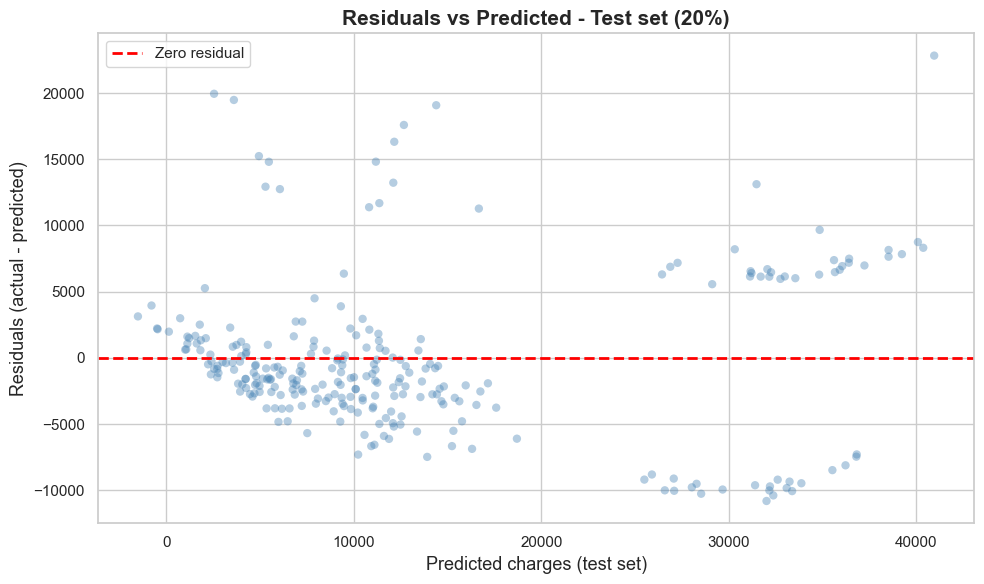

In [387]:
# 5.1.2 - Residuals vs Predicted: test set (out-of-sample heteroscedasticity check)

residuals_test = y_test - y_test_pred

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_test_pred, residuals_test, alpha=0.4, color="steelblue", edgecolors="none")
ax.axhline(0, color="red", linewidth=2, linestyle="--", label="Zero residual")

ax.set_xlabel("Predicted charges (test set)", fontsize=13)
ax.set_ylabel("Residuals (actual - predicted)", fontsize=13)
ax.set_title("Residuals vs Predicted - Test set (20%)", fontsize=15, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()


### 5.1.2 Results - Residuals vs Predicted (test set 20%)

If the residual fan shape appears again out-of-sample, it confirms that
error variance grows with expected charges (heteroscedastic behavior).

This does not invalidate predictive use, but it does mean uncertainty is much
higher for expensive individuals. It also supports the robust-inference
strategy adopted in Section 4 (HC3).


### 5.2 10-fold cross-validation (k=10) + baseline


In [391]:
# 5.2 - 10-fold cross-validation with fold-level table + summary table

if "selected_features_train" not in globals():
    raise RuntimeError("Run Section 5.1 first to define selected_features_train.")

X_cv = X[selected_features_train]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
}

cv_reduced = cross_validate(
    LinearRegression(),
    X_cv,
    y,
    cv=kf,
    scoring=scoring,
)

cv_baseline = cross_validate(
    DummyRegressor(strategy="mean"),
    X_cv,
    y,
    cv=kf,
    scoring=scoring,
)

# 1) Per-fold results (shown first)
fold_idx = np.arange(1, kf.get_n_splits() + 1)

fold_results_reduced = pd.DataFrame({
    "Model": "Reduced model",
    "Fold": fold_idx,
    "R2": cv_reduced["test_R2"],
    "RMSE": -cv_reduced["test_RMSE"],
    "MAE": -cv_reduced["test_MAE"],
})

fold_results_baseline = pd.DataFrame({
    "Model": "Baseline (mean)",
    "Fold": fold_idx,
    "R2": cv_baseline["test_R2"],
    "RMSE": -cv_baseline["test_RMSE"],
    "MAE": -cv_baseline["test_MAE"],
})

cv_fold_results = pd.concat(
    [fold_results_reduced, fold_results_baseline],
    ignore_index=True,
).set_index(["Model", "Fold"])

display(cv_fold_results.round(4))

# 2) Mean/std summary (shown after fold-level results)
cv_summary = cv_fold_results.groupby(level="Model").agg(
    R2_mean=("R2", "mean"),
    R2_std=("R2", "std"),
    RMSE_mean=("RMSE", "mean"),
    RMSE_std=("RMSE", "std"),
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
)

display(cv_summary.round(4))



R2       RMSE        MAE
Model           Fold                              
Reduced model   1     0.7633  5714.6248  4122.0639
                2     0.7937  5965.9291  4289.4274
                3     0.7387  5813.4821  4000.6451
                4     0.7416  6353.6518  4398.4551
                5     0.8146  5781.4600  4306.7316
                6     0.7680  5782.2214  3907.2467
                7     0.6603  6290.7319  4465.9361
                8     0.6098  6507.1551  4236.0570
                9     0.7300  6902.1120  4476.1111
                10    0.7766  5515.3964  3721.8037
Baseline (mean) 1    -0.0019 11756.3312  9267.3989
                2    -0.0002 13134.7858  9885.0184
                3    -0.0002 11375.0114  8253.1964
                4    -0.0028 12515.7447  9537.1422
                5    -0.0273 13610.6057 10000.8022
                6    -0.0013 12012.9746  9169.9541
                7    -0.0004 10796.3077  8061.6727
                8    -0.0102 10470.4185  8102.3452
                9    -0.0044 13310.8789  9833.1201
                10   -0.0108 11732.3076  8847.9784

,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
Model,,,,,,
Baseline (mean),-0.0059,0.0085,12071.5366,1060.6768,9095.8629,748.5565
Reduced model,0.7397,0.0619,6062.6765,433.1718,4192.4478,250.9216


### 5.2 Results - 10-fold detail + summary

The code now displays two validation tables in this order:

1. **Fold-level results (k = 10)** for both reduced model and baseline.
2. **Mean/std summary table** across the 10 folds.

How to interpret:

- The reduced model should have higher R2 and lower RMSE/MAE than baseline in most folds.
- The mean/std table summarizes central performance and stability.
- Moderate fold-to-fold variation is expected in this dataset due to high-cost outliers.

**Validation takeaway:** If the reduced model consistently outperforms baseline
across folds and in mean metrics, generalization is strong enough for portfolio-grade
predictive evidence.



## 6. Multilevel Feasibility Check (Region Effects)

This section tests whether a multilevel structure with `region` as level-2 is
empirically justified in this dataset.


### 6.1 Motivation

Why run this check:
- Individuals are nested within `region`.
- Mixed-effects models can be useful if between-region variance is non-negligible.

Caution:
- We only have **4 regions**, so random-slope inference would be unstable.
- We therefore start with a null random-intercept model and use ICC + LRT to
  decide whether deeper multilevel modeling is worthwhile.


### 6.2 Quick diagnostics by region


,n
region,
northeast,324
northwest,325
southeast,364
southwest,325


,n,mean,median,std,min,max
region,,,,,,
northeast,324,13406.3800,10057.6500,11255.8000,1694.8000,58571.0700
northwest,325,12417.5800,8965.8000,11072.2800,1621.3400,60021.4000
southeast,364,14735.4100,9294.1300,13971.1000,1121.8700,63770.4300
southwest,325,12346.9400,8798.5900,11557.1800,1241.5600,52590.8300


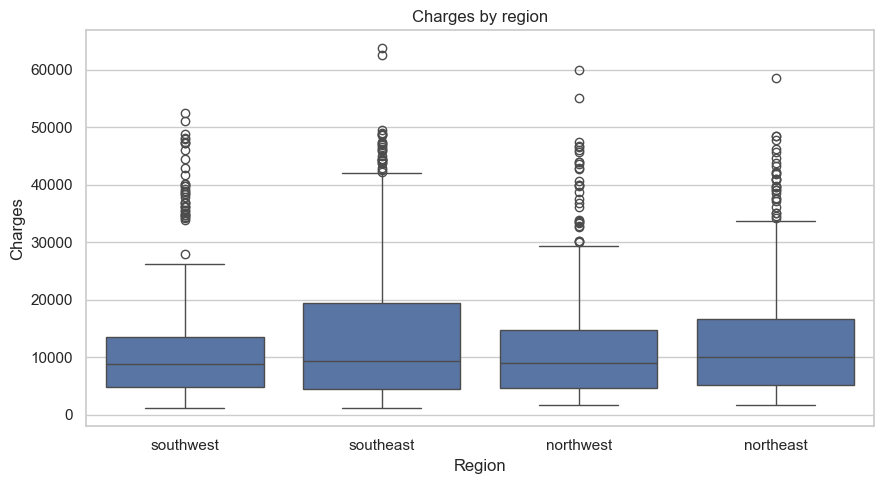

In [394]:
# 6.2 - Quick region diagnostics

region_counts = df['region'].value_counts().sort_index().to_frame('n')
display(region_counts)

region_summary = df.groupby('region')['charges'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
)
display(region_summary.round(2))

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges by region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()


### 6.2 Results - Region diagnostics

- Region sizes are balanced (roughly 324 to 364 observations each).
- There are visible differences in central tendency and spread across regions,
  but distributions still overlap substantially.
- This motivates a formal check of region-level variance via a null mixed model.


### 6.3 Null mixed model (random intercept) and significance


In [396]:
# 6.3 - Null model: charges ~ 1 + (1 | region) with significance output

# Fit null mixed model with ML (preferred for likelihood-ratio comparison)
mix_null_ml = smf.mixedlm('charges ~ 1', data=df, groups=df['region']).fit(
    reml=False, method='lbfgs'
)

# Fallback if optimizer returns non-finite likelihood
if not np.isfinite(mix_null_ml.llf):
    mix_null_ml = smf.mixedlm('charges ~ 1', data=df, groups=df['region']).fit(
        reml=False, method='powell', maxiter=300
    )

print(mix_null_ml.summary())

# Variance components and ICC
var_region = float(mix_null_ml.cov_re.iloc[0, 0])
var_resid = float(mix_null_ml.scale)
icc = var_region / (var_region + var_resid)

# Significance of region random effect via LRT against intercept-only OLS
ols_null = smf.ols('charges ~ 1', data=df).fit()
lr_stat = 2 * (mix_null_ml.llf - ols_null.llf)

# Standard chi-square p-value (1 df)
p_chi2 = stats.chi2.sf(lr_stat, 1)

# Boundary-adjusted p-value for variance components (recommended approximation)
p_boundary = 0.5 * p_chi2

alpha = 0.05
region_effect_significant = p_boundary < alpha

null_results = pd.DataFrame({
    'metric': [
        'Region variance (u0)',
        'Residual variance (e)',
        'ICC',
        'LRT statistic (2*LL diff)',
        'p-value (chi-square, 1 df)',
        'p-value (boundary-adjusted)',
    ],
    'value': [
        var_region,
        var_resid,
        icc,
        lr_stat,
        p_chi2,
        p_boundary,
    ]
})

display(null_results.round(6))

print()
print('Decision at alpha = 0.05:')
if region_effect_significant:
    print('- Region-level random intercept variance is statistically significant.')
    print('- Region contributes non-negligible between-group variability in charges.')
else:
    print('- Region-level random intercept variance is NOT statistically significant.')
    print('- Between-region variance appears small; ICC suggests weak clustering effect.')

print()
print(f"ICC interpretation: {icc:.4f} ({icc*100:.2f}% of total variance at region level)")


            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: charges       
No. Observations:   1338    Method:             ML            
No. Groups:         4       Scale:              145999155.7311
Min. group size:    324     Log-Likelihood:     -14476.7382   
Max. group size:    364     Converged:          Yes           
Mean group size:    334.5                                     
--------------------------------------------------------------
            Coef.    Std.Err.   z    P>|z|   [0.025    0.975] 
--------------------------------------------------------------
Intercept  13245.734  492.354 26.903 0.000 12280.738 14210.731
Group Var 531829.649   55.765                                 



,metric,value
0,Region variance (u0),531829.6489
1,Residual variance (e),145999155.7311
2,ICC,0.0036
3,LRT statistic (2*LL diff),1.7869
4,"p-value (chi-square, 1 df)",0.1813
5,p-value (boundary-adjusted),0.0907



Decision at alpha = 0.05:
- Region-level random intercept variance is NOT statistically significant.
- Between-region variance appears small; ICC suggests weak clustering effect.

ICC interpretation: 0.0036 (0.36% of total variance at region level)


### 6.3 Results - Feasibility decision

From the current output:

- Region variance (`u0`) ~= **531,829.65**
- Residual variance (`e`) ~= **145,999,155.73**
- **ICC ~= 0.0036** (about **0.36%** of total variance at region level)
- LRT statistic ~= **1.7869**
- Boundary-adjusted p-value ~= **0.0907**

At `alpha = 0.05`, we do **not** reject the null of negligible region-level
random-intercept variance.


### 6.4 Final conclusion for modelling strategy

Given the very small ICC and non-significant boundary-adjusted LRT result,
there is limited empirical support for a full multilevel expansion in this
specific dataset.

Decision:
- Keep multilevel analysis as a **feasibility check**.
- Maintain the validated single-level strategy from Sections 4 and 5 as the
  primary modelling framework.

**Business takeaway:** In this dataset, individual-level risk factors (especially
smoking, age and BMI) dominate pricing signal, while region-level random effects
add limited incremental value.


## 7. Final Conclusion and Model Recommendation

### 7.1 General conclusion

This project combined EDA, inferential statistics, model diagnostics and
out-of-sample validation to explain medical insurance charges.

Main findings:

- Smoking is the strongest cost driver in the dataset (large and robust effect).
- Age and BMI are also relevant positive predictors of charges.
- Children has a smaller but meaningful contribution.
- The target (`charges`) is heavy-tailed and heteroscedastic, so robust inference is important.

### 7.2 Final recommended model

**Recommended final model:** a **reduced single-level linear regression** on the
original `charges` scale, using:

- `age`
- `bmi`
- `children`
- `smoker_yes`

For inference, use **HC3 robust standard errors**.

Why this model:

- It is parsimonious and interpretable.
- It generalizes well out-of-sample.
- It clearly outperforms the mean baseline.
- It is consistent with domain logic for risk-based pricing.

### 7.3 Validation evidence

Leak-safe train/test workflow and 10-fold CV show stable performance:

- Train: R2 = 0.7411, RMSE = 6113.07, MAE = 4210.66
- Test: R2 = 0.7811, RMSE = 5829.38, MAE = 4213.80
- 10-fold CV (reduced model):
  - R2 mean = 0.7397 (std = 0.0619)
  - RMSE mean = 6062.68 (std = 433.17)
  - MAE mean = 4192.45 (std = 250.92)

Baseline comparison is substantially worse (R2 near or below 0), confirming
that the reduced model captures meaningful predictive signal.

### 7.4 Multilevel feasibility conclusion

A multilevel feasibility check with `region` as level-2 found weak clustering:

- ICC ~= 0.0036 (0.36%)
- boundary-adjusted p-value ~= 0.0907

Therefore, region-level random effects add limited incremental value in this
specific dataset, and the validated single-level model remains the best
practical choice.

### 7.5 Practical business takeaway

For pricing/risk support in this dataset, the most important drivers are
**smoking, age and BMI**. The final reduced model provides a strong balance of
interpretability and predictive performance, with caution that uncertainty is
higher for very high-cost individuals.
